# Étape 99 (3/3a) — graphiques

Version "hors Excel" des graphiques du classeur final (voir `graphiques.py`) : des fonctions
réutilisables, chacune prenant un DataFrame déjà chargé et retournant `(fig, ax)` - pour un notebook,
un rapport, ou toute autre restitution qui n'est pas un classeur Excel.

## 0. Charger les tables — [`pipeline.py`](pipeline.py)

In [1]:
import sys
from pathlib import Path

ICI = Path.cwd()
sys.path.insert(0, str(ICI))
RACINE = ICI.parents[1]

import pandas as pd
import matplotlib.pyplot as plt

DOSSIER_BKT = RACINE / "data" / "donnees_valides" / "bkt"
indicateurs = pd.read_csv(DOSSIER_BKT / "indicateurs.csv")
ic = pd.read_csv(DOSSIER_BKT / "ic_standard.csv")
detail_cluster = pd.read_csv(DOSSIER_BKT / "bkt_final_detail_par_cluster.csv")
print(f"{len(indicateurs)} années chargées")

7 années chargées


## 1. `bkt_national` — la vue de synthèse

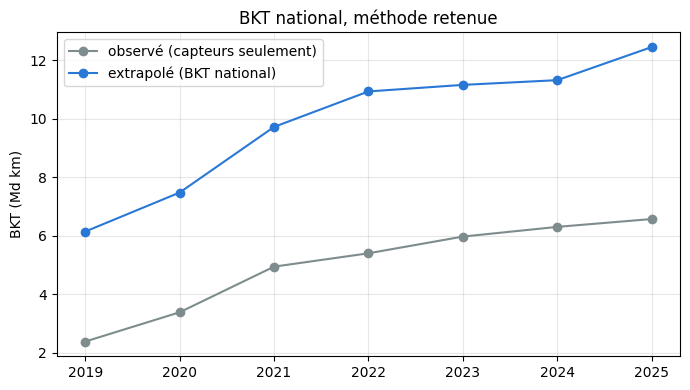

In [2]:
import graphiques as G

fig, ax = G.bkt_national(indicateurs)
plt.show()

## 2. `bkt_avec_intervalle_confiance`

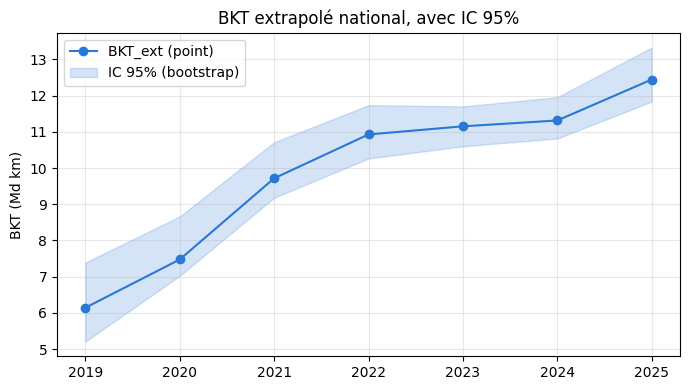

In [3]:
fig, ax = G.bkt_avec_intervalle_confiance(indicateurs, ic)
plt.show()

## 3. `bkt_standard_vs_mini` — test de robustesse

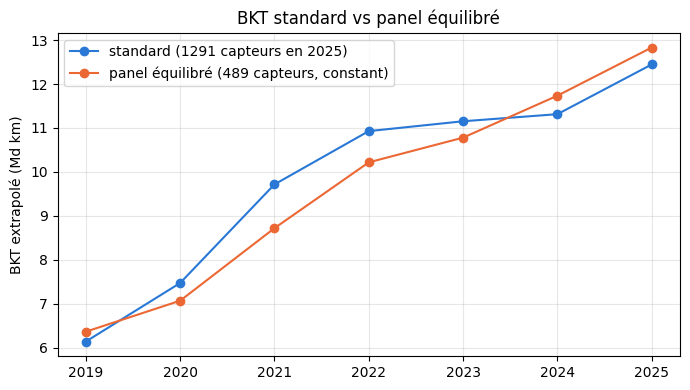

In [4]:
fig, ax = G.bkt_standard_vs_mini(indicateurs)
plt.show()

## 4. `indice_base_100` — plusieurs indicateurs, unités différentes

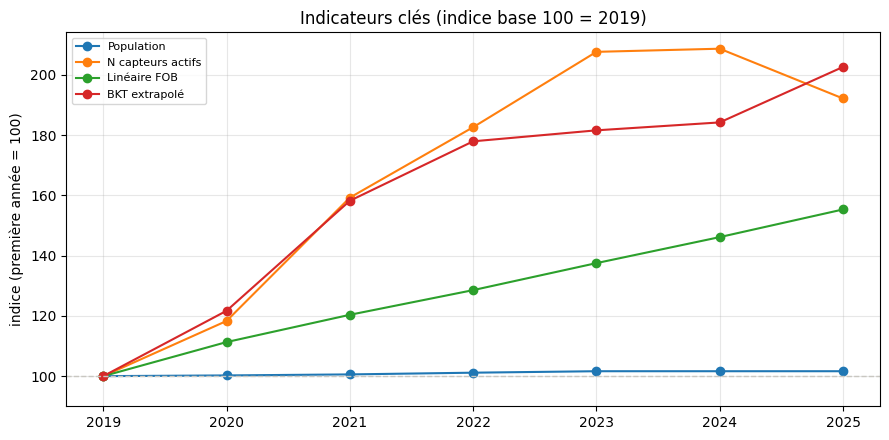

In [5]:
fig, ax = G.indice_base_100(
    indicateurs,
    {"population": "Population", "n_capteurs_actifs": "N capteurs actifs", "lineaire_fob_km": "Linéaire FOB", "bkt_ext_Mdkm": "BKT extrapolé"},
    titre="Indicateurs clés (indice base 100 = 2019)",
)
plt.show()

## 5. `taux_par_cluster` — qui roule le plus par km de réseau ?

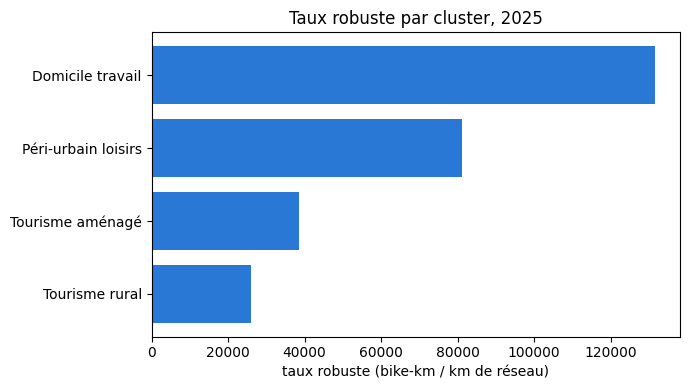

In [6]:
fig, ax = G.taux_par_cluster(detail_cluster, annee=2025)
plt.show()

## Bilan

`graphiques.py` couvre les mêmes vues que la feuille "Résumé"/"Indicateurs de base" du classeur Excel
(`export_excel.py`), mais comme des fonctions matplotlib indépendantes, réutilisables dans n'importe
quel contexte (notebook, rapport, script de restitution) sans dépendre de xlsxwriter.